In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [68]:
df=pd.read_csv("/content/Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [70]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [71]:
df[df.isnull()]

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
df.NumberOfChildrenVisiting.value_counts()

,count
NumberOfChildrenVisiting,
1.0,2080
2.0,1335
0.0,1082
3.0,325


In [73]:
df.TypeofContact.value_counts()

,count
TypeofContact,
Self Enquiry,3444
Company Invited,1419


In [74]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [75]:
df.CityTier.value_counts()

,count
CityTier,
1,3190
3,1500
2,198


In [76]:
df.Gender.value_counts()

,count
Gender,
Male,2916
Female,1817
Fe Male,155


In [77]:
df["Gender"]=df["Gender"].str.replace("Fe Male","Female")

In [78]:
df.Gender.value_counts()

,count
Gender,
Male,2916
Female,1972


In [79]:
df.Occupation.value_counts()

,count
Occupation,
Salaried,2368
Small Business,2084
Large Business,434
Free Lancer,2


## Group all the column names with Nan values

In [80]:
features_with_nan= [feature for feature in df.columns if df[feature].isnull().sum()>=1]
features_with_nan
for name in features_with_nan:
  print(f"{name}, {np.round(df[name].isnull().mean(),2)*100} % missing values")

Age, 5.0 % missing values
TypeofContact, 1.0 % missing values
DurationOfPitch, 5.0 % missing values
NumberOfFollowups, 1.0 % missing values
PreferredPropertyStar, 1.0 % missing values
NumberOfTrips, 3.0 % missing values
NumberOfChildrenVisiting, 1.0 % missing values
MonthlyIncome, 5.0 % missing values


## Stats of NAN data

In [81]:
df[features_with_nan].select_dtypes(exclude="object").describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Imputing of Null Values

In [82]:
## Mean Imputation
mean_list= []
mode_list=["NumberOfFollowups","TypeofContact","NumberOfChildrenVisiting"]
median_list=["Age","DurationOfPitch","NumberOfTrips","MonthlyIncome"]
for features in features_with_nan:
  if features in mean_list:
    df[features]=df[features].fillna(df[features].mean())
  elif features in mode_list:
    print(f"Performing Mode Impuation on {features}")
    df[features]=df[features].fillna(df[features].mode()[0])
  else:
    print(f"Performing Median Impuation on {features}")
    df[features]=df[features].fillna(df[features].median())

Performing Median Impuation on Age
Performing Mode Impuation on TypeofContact
Performing Median Impuation on DurationOfPitch
Performing Mode Impuation on NumberOfFollowups
Performing Median Impuation on PreferredPropertyStar
Performing Median Impuation on NumberOfTrips
Performing Mode Impuation on NumberOfChildrenVisiting
Performing Median Impuation on MonthlyIncome


In [83]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,0
TypeofContact,0
CityTier,0
DurationOfPitch,0
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,0


In [84]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [85]:
df.drop("CustomerID", axis=1, inplace=True)

In [86]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [87]:
df["TotalVisitings"]= df["NumberOfChildrenVisiting"] + df ["NumberOfPersonVisiting"]

df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,TotalVisitings
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0,2.0


In [88]:
df.drop(["NumberOfChildrenVisiting","NumberOfPersonVisiting"], axis=1, inplace=True)

In [89]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisitings
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProdTaken               4888 non-null   int64  
 1   Age                     4888 non-null   float64
 2   TypeofContact           4888 non-null   object 
 3   CityTier                4888 non-null   int64  
 4   DurationOfPitch         4888 non-null   float64
 5   Occupation              4888 non-null   object 
 6   Gender                  4888 non-null   object 
 7   NumberOfFollowups       4888 non-null   float64
 8   ProductPitched          4888 non-null   object 
 9   PreferredPropertyStar   4888 non-null   float64
 10  MaritalStatus           4888 non-null   object 
 11  NumberOfTrips           4888 non-null   float64
 12  Passport                4888 non-null   int64  
 13  PitchSatisfactionScore  4888 non-null   int64  
 14  OwnCar                  4888 non-null   

In [91]:
num_feat=[feat for feat in df.columns if df[feat].dtype !="object"]
print(f"{num_feat}, \n{len(num_feat)}")

['ProdTaken', 'Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisitings'], 
12


In [92]:
cat_feat=[feat for feat in df.columns if df[feat].dtype == "object"]
print(f"{cat_feat}, \n{len(cat_feat)}")

['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation'], 
6


In [93]:
discrete_feat= [feat for feat in num_feat if len(df[feat].unique())<=25]
print(f"Discrete Features= {discrete_feat} \n {len(discrete_feat)}")

Discrete Features= ['ProdTaken', 'CityTier', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'TotalVisitings'] 
 9


In [94]:
continous= [feat for feat in num_feat if feat not in discrete_feat]
print(f"continous Features= {continous} \n {len(continous)}")

continous Features= ['Age', 'DurationOfPitch', 'MonthlyIncome'] 
 3


In [95]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisitings
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [96]:
X=df.drop(["ProdTaken"], axis=1)
y=df["ProdTaken"]

In [97]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20, stratify=y,random_state=7)
print(X_train.shape)
print(y_train.shape)

(3910, 17)
(3910,)


In [98]:
y.value_counts()

,count
ProdTaken,
0,3968
1,920


In [99]:
cat_feat=X.select_dtypes(include="object").columns
num_feat=X.select_dtypes(exclude="object").columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer

cv= ColumnTransformer([
    ("onehotencoder",OneHotEncoder(drop="first"),cat_feat),
    ("standardscaler",StandardScaler(),num_feat)
])
cv

ColumnTransformer(transformers=[('onehotencoder', OneHotEncoder(drop='first'),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')),
                                ('standardscaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisitings'],
      dtype='object'))])

In [100]:
## Apply on Xtrain and X_test

X_train= cv.fit_transform(X_train)
X_test=cv.transform(X_test)

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report,f1_score,precision_score, recall_score

models={
    "RandomForest": RandomForestClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier()
}

for i in range(len(list(models))):
  name=list(models.keys())[i]
  model=list(models.values())[i]

  ## train on data
  model.fit(X_train,y_train)

  ## Predict
  y_train_pred= model.predict(X_train)
  y_test_pred=model.predict(X_test)

  ## Metrics
  train_metrics= {
      "Accuarcy_score": accuracy_score(y_train,y_train_pred),
      "f1_score ": f1_score(y_train,y_train_pred),
      "precision_score": precision_score(y_train,y_train_pred),
      "recall_score": recall_score(y_train,y_train_pred),
      #"classification_report": classification_report(y_train,y_train_pred)
  }
  test_metrics= {
      "Accuarcy_score": accuracy_score(y_test,y_test_pred),
      "f1_score ": f1_score(y_test,y_test_pred),
      "precision_score": precision_score(y_test,y_test_pred),
      "recall_score": recall_score(y_test,y_test_pred),
      #"classification_report": classification_report(y_test,y_test_pred)
  }

  ## Training Metrics
  print("="*50)
  print(f"Model Name:{name} \n {'='*60}")
  for name_met, val_met in train_metrics.items():
    print(f"{name_met} : {val_met}")
  print("="*50)
  print("Test Data Metrics")
  print("="*50)
  for name_met, val_met in train_metrics.items():
    print(f"{name_met} : {val_met}")
  print("="*50)


Model Name:RandomForest 
Accuarcy_score : 1.0
f1_score  : 1.0
precision_score : 1.0
recall_score : 1.0
Test Data Metrics
Accuarcy_score : 1.0
f1_score  : 1.0
precision_score : 1.0
recall_score : 1.0
Model Name:DecisionTreeClassifier 
Accuarcy_score : 1.0
f1_score  : 1.0
precision_score : 1.0
recall_score : 1.0
Test Data Metrics
Accuarcy_score : 1.0
f1_score  : 1.0
precision_score : 1.0
recall_score : 1.0


## Perform Hyper parameter Tuning

In [102]:
params={
    "max_depth": [5, 8, 15, None, 10],
    "max_features": [5, 7, "auto", 8],
    "min_samples_split": [2, 8, 15, 20],
    "n_estimators": [100, 200, 500, 1000]
}
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
def hyperparams_tune(models,params,X_train,y_train,ch="grid"):
  result={}
  for name, model in models.items():
    name=name
    model=model
    #cv=StratifiedKFold()
    cv=3
    ## perform grid search cv
    if ch.lower()=="grid":
      gs=GridSearchCV(estimator=model,param_grid=params,cv=cv,scoring="accuracy",refit=True,verbose=2,n_jobs=-1)
      gs.fit(X_train,y_train)
      result[name]= gs.best_params_
      print(f"Best Params : {gs.best_params_}")
      print(f"Best Score : {gs.best_score_}")
      models[name].set_params(**gs.best_score_)
    else:
      rnd= RandomizedSearchCV(estimator=model,param_distributions=params,cv=cv,scoring="accuracy",refit=True,verbose=2,n_jobs=-1)
      rnd.fit(X_train,y_train)
      print(f"Best Params : {rnd.best_params_}")
      print(f"Best Score : {rnd.best_score_}")
      result[name]= rnd.best_params_
      models[name].set_params(**rnd.best_params_)
    return models

# hyperparams_tune(models,params,X_train,y_train,ch="rnd")




In [103]:
result=hyperparams_tune(models,params,X_train,y_train,ch="rnd")
print(result)




Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params : {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 8, 'max_depth': 10}
Best Score : 0.8805632981620203
{'RandomForest': RandomForestClassifier(max_depth=10, max_features=8, n_estimators=500), 'DecisionTreeClassifier': DecisionTreeClassifier()}


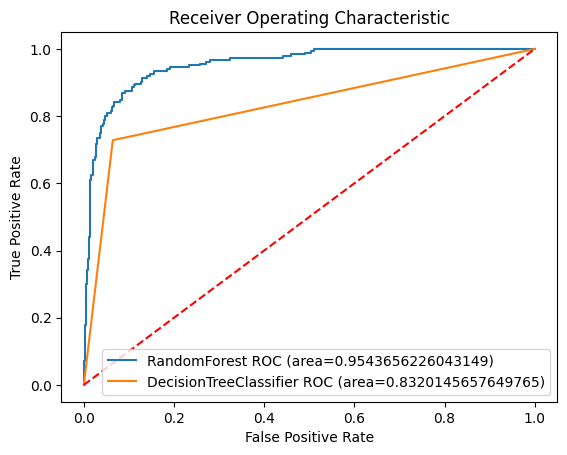

In [104]:
from sklearn.metrics import roc_auc_score, roc_curve
## assuming you have the roc and auc score values
for name, model in result.items():
  model=model.fit(X_train,y_train)
  y_test_score=model.predict_proba(X_test)[:,1]
  fpr,tpr, thresholds= roc_curve(y_test,y_test_score)
  plt.plot(fpr,tpr,label=f"{name} ROC (area={roc_auc_score(y_test,y_test_score)})")
plt.plot([0,1],[0,1],"r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show()

In [105]:
len(np.unique(y_test))

2

In [106]:
from sklearn.preprocessing import label_binarize

Performing Hyper Parameter Tuning on Model-RandomForest
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Model: RandomForest
Best Params : {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 8, 'max_depth': 10}
Best Score : 0.9099782442984724
Performing Hyper Parameter Tuning on Model-DecisionTree
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Model: DecisionTree
Best Params : {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
Best Score : 0.808253462757227
{'RandomForest': RandomForestClassifier(max_depth=10, max_features=8, n_estimators=500), 'DecisionTree': DecisionTreeClassifier(max_depth=20, min_samples_split=10)}
['RandomForest', 'DecisionTree']
Model Name:RandomForest 
Accuarcy_score : 0.9544757033248081
f1_score  : 0.9519654379189237
precision_score : 0.956893162993121
recall_score : 0.9544757033248081
Test Data Metrics
Accuarcy_score : 0.9544757033248081
f1_score  : 0.9519654379189237
precision_score : 0.956893162993121
recall

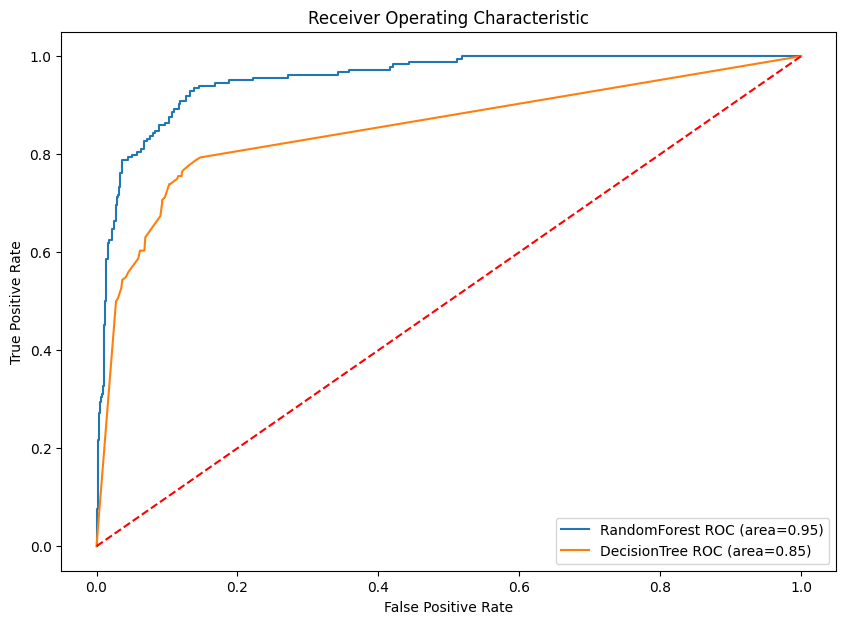

In [107]:
import warnings
warnings.filterwarnings("ignore")
def evaluate(models, X_train,y_train,X_test,y_test):
  print(list(models))
  for i in range(len(list(models))):
    name=list(models.keys())[i]
    model=list(models.values())[i]
    ## train on data
    model.fit(X_train,y_train)
    ## Predict
    y_train_pred= model.predict(X_train)
    y_test_pred=model.predict(X_test)

    ## Metrics
    train_metrics= {
        "Accuarcy_score": accuracy_score(y_train,y_train_pred),
        "f1_score ": f1_score(y_train,y_train_pred,average='weighted'),
        "precision_score": precision_score(y_train,y_train_pred,average='weighted'),
        "recall_score": recall_score(y_train,y_train_pred,average='weighted'),
        #"roc_auc_score": roc_auc_score(y_train,y_train_pred),
        #"classification_report": classification_report(y_train,y_train_pred)
    }
    test_metrics= {
        "Accuarcy_score": accuracy_score(y_test,y_test_pred),
        "f1_score ": f1_score(y_test,y_test_pred,average='weighted'),
        "precision_score": precision_score(y_test,y_test_pred,average='weighted'),
        "recall_score": recall_score(y_test,y_test_pred,average='weighted'),
        #"roc_auc_score": roc_auc_score(y_test,y_test_pred),
        #"classification_report": classification_report(y_test,y_test_pred)
    }
    ## Training Metrics
    print("="*50)
    print(f"Model Name:{name} \n {'='*60}")
    for name_met, val_met in train_metrics.items():
      print(f"{name_met} : {val_met}")
    print("="*50)
    print("Test Data Metrics")
    print("="*50)
    for name_met, val_met in train_metrics.items():
      print(f"{name_met} : {val_met}")
    print("="*50)
    if len(np.unique(y_test))==2:
       # Binary Classification
       y_test_proba=model.predict_proba(X_test)[:,1]
       y_test_score=roc_auc_score(y_test,y_test_proba)
       test_metrics["roc_auc_score"] = y_test_score
    else:
      y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
      y_test_proba = model.predict_proba(X_test)
      test_metrics['roc_auc_score'] = roc_auc_score(y_test_bin, y_test_proba, average='weighted', multi_class='ovr')
      print("Use Multi class as more than one type")


def hyperparams_tune(models,params,X_train,y_train,ch="grid"):
  result={}
  for name, model in models.items():
    name=name
    model=model
    #cv=StratifiedKFold()
    cv=3
    print(f"Performing Hyper Parameter Tuning on Model-{name}")
    if name in list(params.keys()):
        param_vals= params[name]
        ## perform grid search cv
        if ch.lower()=="grid":
          gs=GridSearchCV(estimator=model,param_grid=param_vals,cv=cv,scoring="roc_auc",refit=True,verbose=2,n_jobs=-1)
          gs.fit(X_train,y_train)
          result[name]= gs.best_params_
          print(f"Best Params : {gs.best_params_}")
          print(f"Best Score : {gs.best_score_}")
          models[name].set_params(**gs.best_score_)
        else:
          rnd= RandomizedSearchCV(estimator=model,param_distributions=param_vals,cv=cv,scoring="roc_auc",refit=True,verbose=2,n_jobs=-1)
          rnd.fit(X_train,y_train)
          print(f"Model: {name}")
          print(f"Best Params : {rnd.best_params_}")
          print(f"Best Score : {rnd.best_score_}")
          result[name]= rnd.best_params_
          models[name].set_params(**rnd.best_params_)
    else:
      print(f"The hyper parameters for the respective models {params.keys()} not found")
  return models

def plot_roc_auc_curve(result,X_test,y_test):
  plt.figure(figsize=(10,7))
  for name, model in result.items():
    # model=model.fit(X_train,y_train)
    y_test_proba=model.predict_proba(X_test)[:,1]
    fpr,tpr, thresholds= roc_curve(y_test,y_test_proba)
    y_test_roc=roc_auc_score(y_test,y_test_proba)
    plt.plot(fpr,tpr,label=f"{name} ROC (area={y_test_roc:_.2f})")
  plt.plot([0,1],[0,1],"r--")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("Receiver Operating Characteristic")
  plt.legend(loc="lower right")
  plt.savefig("auc1.png")
  plt.show()

  ## main script
models={
    "RandomForest": RandomForestClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}
params={
    "DecisionTree": {
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "RandomForest": {
        "max_depth": [5, 8, 15, None, 10],
        "max_features": [5, 7, "auto", 8],
        "min_samples_split": [2, 8, 15, 20],
        "n_estimators": [100, 200, 500, 1000]
    }
}

models= hyperparams_tune(models,params,X_train,y_train,ch="rnd")
print(models)
evaluate(models,X_train,y_train,X_test,y_test)
plot_roc_auc_curve(models,X_test,y_test)




In [ ]:
for i in range(len(list(models))):
    name=list(models.keys())[i]
    model=list(models.values())[i]
    cv=3
    if name in list(params.keys()):
        param_vals= params[name]
        print(param_vals)
        ## perform grid search cv
        if ch.lower()=="grid":
          gs=GridSearchCV(estimator=model,param_grid=param_vals,cv=cv,scoring="accuracy",refit=True,verbose=2,n_jobs=-1)
          gs.fit(X_train,y_train)
          result[name]= gs.best_params_
          print(f"Best Params : {gs.best_params_}")
          print(f"Best Score : {gs.best_score_}")
          models[name].set_params(**gs.best_score_)
        else:
          rnd= RandomizedSearchCV(estimator=model,param_distributions=param_vals,cv=cv,scoring="accuracy",refit=True,verbose=2,n_jobs=-1)
          rnd.fit(X_train,y_train)
          print(f"Best Params : {rnd.best_params_}")
          print(f"Best Score : {rnd.best_score_}")
          result[name]= rnd.best_params_
          models[name].set_params(**rnd.best_params_)
    else:
      print(f"The hyper parameters for the respective models {params.keys()} not found")